In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import nltk
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix,accuracy_score

import keras
#from keras.preprocessing import text,sequence
from keras.models import Sequential
from keras.layers import Dense,Embedding,LSTM,Dropout
import tensorflow as tf
import warnings
import tensorflow_hub as hub

warnings.filterwarnings('ignore')


2025-05-30 08:46:43.343191: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748594803.545302      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748594803.604060      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
df_captions = pd.read_csv("/kaggle/input/flickr8k/captions.txt")

In [3]:
df_captions[0:20]

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
6,1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with...
7,1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots a...
8,1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each o...
9,1001773457_577c3a7d70.jpg,Two dogs on pavement moving toward each other .


In [4]:
print(df_captions[df_captions['image'] =='1001773457_577c3a7d70.jpg'].caption)

5           A black dog and a spotted dog are fighting
6    A black dog and a tri-colored dog playing with...
7    A black dog and a white dog with brown spots a...
8    Two dogs of different breeds looking at each o...
9      Two dogs on pavement moving toward each other .
Name: caption, dtype: object


In [5]:
len(df_captions[df_captions['image'] =='1000268201_693b08cb0e.jpg'].caption)

5

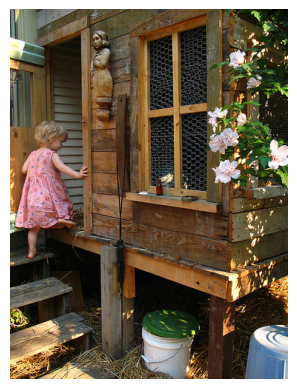

A child in a pink dress is climbing up a set of stairs in an entry way .
A girl going into a wooden building .
A little girl climbing into a wooden playhouse .
A little girl climbing the stairs to her playhouse .
A little girl in a pink dress going into a wooden cabin .


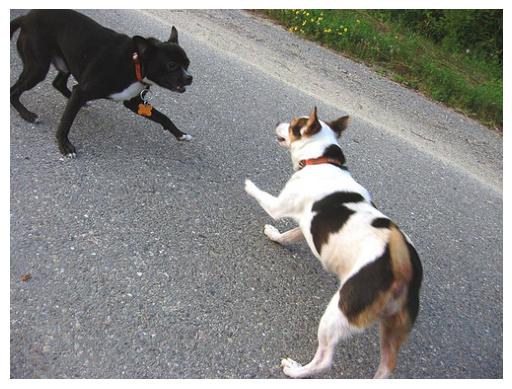

A black dog and a spotted dog are fighting
A black dog and a tri-colored dog playing with each other on the road .
A black dog and a white dog with brown spots are staring at each other in the street .
Two dogs of different breeds looking at each other on the road .
Two dogs on pavement moving toward each other .


In [6]:
from PIL import Image
import matplotlib.pyplot as plt
last_image = "khali"
counter = 0
for image in df_captions.image[0:10]:
    if image != last_image:
        img = Image.open('/kaggle/input/flickr8k/Images/'+str(image))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        #print(len(df_captions[df_captions['image'] == image].caption))
        captions = df_captions[df_captions['image'] == image].caption
        for i in range(len(captions)):
            print(captions.iloc[i])
        last_image = str(image)

In [7]:
type(df_captions.image)

pandas.core.series.Series

In [8]:
df_captions.caption

0        A child in a pink dress is climbing up a set o...
1                    A girl going into a wooden building .
2         A little girl climbing into a wooden playhouse .
3        A little girl climbing the stairs to her playh...
4        A little girl in a pink dress going into a woo...
                               ...                        
40450             A man in a pink shirt climbs a rock face
40451             A man is rock climbing high in the air .
40452    A person in a red shirt climbing up a rock fac...
40453                      A rock climber in a red shirt .
40454    A rock climber practices on a rock climbing wa...
Name: caption, Length: 40455, dtype: object

In [9]:
from bs4 import BeautifulSoup
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
lemma = WordNetLemmatizer()

#remove_HTML_tags
def remove_html(text):
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text()

#punctuation marks
def remove_punctuations(text):
    return re.sub(r'[^\w\s]', '', text)  # Remove all non-alphanumeric characters except spaces

#remove_special_characters
def remove_characters(text):
    return re.sub(r'[^a-zA-Z\s]', ' ', text)

#remove_stopwords_and_lemmatization
def remove_stopwords_and_lemmatization(text):
    final_text = []
    text = text.lower()
    text = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    
    for word in text:
        if word not in stop_words:
            word = lemma.lemmatize(word)
            final_text.append(word)
    return " ".join(final_text)

#cleaning function
def cleaning(text):
    text = remove_html(text)
    text = remove_punctuations(text)
    text = remove_characters(text)
    text = remove_stopwords_and_lemmatization(text)
    return text

df_captions['caption'] = df_captions['caption'].apply(cleaning)

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [10]:
df_captions

,image,caption
0,1000268201_693b08cb0e.jpg,child pink dress climbing set stair entry way
1,1000268201_693b08cb0e.jpg,girl going wooden building
2,1000268201_693b08cb0e.jpg,little girl climbing wooden playhouse
3,1000268201_693b08cb0e.jpg,little girl climbing stair playhouse
4,1000268201_693b08cb0e.jpg,little girl pink dress going wooden cabin
...,...,...
40450,997722733_0cb5439472.jpg,man pink shirt climb rock face
40451,997722733_0cb5439472.jpg,man rock climbing high air
40452,997722733_0cb5439472.jpg,person red shirt climbing rock face covered as...
40453,997722733_0cb5439472.jpg,rock climber red shirt


In [11]:
import json
#vocabulary_dictionary_special tokens
def build_vocabulary(texts):
    vocab = {
        '<pad>': 0,
        '<sos>': 1,
        '<eos>': 2,
        '<unk>': 3
    }
    word_id = len(vocab)
    
    for text in texts:
        words = text.split()
        for word in words:
            if word not in vocab:
                vocab[word] = word_id
                word_id += 1
    
    return vocab

vocab = build_vocabulary(df_captions['caption'])

#save_vocabulary
with open('tokenizer_vocab.json', 'w') as f:
    json.dump(vocab, f, indent=4)
    
print("Vocabulary size:", len(vocab))
print("Sample vocabulary:", {k: vocab[k] for k in list(vocab)[:10]})

Vocabulary size: 7462
Sample vocabulary: {'<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3, 'child': 4, 'pink': 5, 'dress': 6, 'climbing': 7, 'set': 8, 'stair': 9}


In [12]:
def counter_caption_words(texts):
        words = texts.split()
        return len(words)

In [13]:
df_captions['numberofWORDS'] = df_captions['caption'].apply(counter_caption_words)

In [14]:
df_captions

,image,caption,numberofWORDS
0,1000268201_693b08cb0e.jpg,child pink dress climbing set stair entry way,8
1,1000268201_693b08cb0e.jpg,girl going wooden building,4
2,1000268201_693b08cb0e.jpg,little girl climbing wooden playhouse,5
3,1000268201_693b08cb0e.jpg,little girl climbing stair playhouse,5
4,1000268201_693b08cb0e.jpg,little girl pink dress going wooden cabin,7
...,...,...,...
40450,997722733_0cb5439472.jpg,man pink shirt climb rock face,6
40451,997722733_0cb5439472.jpg,man rock climbing high air,5
40452,997722733_0cb5439472.jpg,person red shirt climbing rock face covered as...,9
40453,997722733_0cb5439472.jpg,rock climber red shirt,4


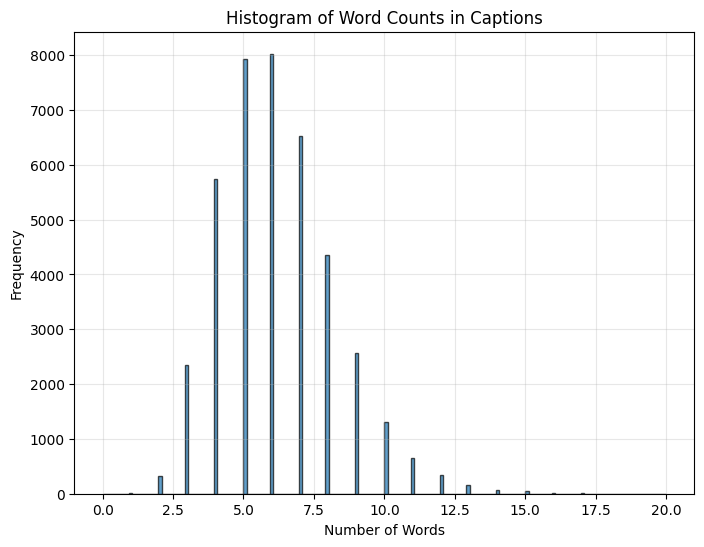

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8, 6))
plt.hist(df_captions['numberofWORDS'], bins='auto', edgecolor='black', alpha=0.7)
plt.title('Histogram of Word Counts in Captions')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

In [16]:
def padding(texts):
    words = texts.split()
    if len(words) < 20:
        words = ['<sos>'] + words
        for i in range(20 - len(words) - 1):
            words.append('<pad>')
        words = words + ['<eos>']
    text = ' '.join(str(item) for item in words)
    return text

In [17]:
df_captions['caption'] = df_captions['caption'].apply(padding)

In [18]:
df_captions

,image,caption,numberofWORDS
0,1000268201_693b08cb0e.jpg,<sos> child pink dress climbing set stair entr...,8
1,1000268201_693b08cb0e.jpg,<sos> girl going wooden building <pad> <pad> <...,4
2,1000268201_693b08cb0e.jpg,<sos> little girl climbing wooden playhouse <p...,5
3,1000268201_693b08cb0e.jpg,<sos> little girl climbing stair playhouse <pa...,5
4,1000268201_693b08cb0e.jpg,<sos> little girl pink dress going wooden cabi...,7
...,...,...,...
40450,997722733_0cb5439472.jpg,<sos> man pink shirt climb rock face <pad> <pa...,6
40451,997722733_0cb5439472.jpg,<sos> man rock climbing high air <pad> <pad> <...,5
40452,997722733_0cb5439472.jpg,<sos> person red shirt climbing rock face cove...,9
40453,997722733_0cb5439472.jpg,<sos> rock climber red shirt <pad> <pad> <pad>...,4


In [19]:
df_captions['numberofWORDS'] = df_captions['caption'].apply(counter_caption_words)
df_captions

,image,caption,numberofWORDS
0,1000268201_693b08cb0e.jpg,<sos> child pink dress climbing set stair entr...,20
1,1000268201_693b08cb0e.jpg,<sos> girl going wooden building <pad> <pad> <...,20
2,1000268201_693b08cb0e.jpg,<sos> little girl climbing wooden playhouse <p...,20
3,1000268201_693b08cb0e.jpg,<sos> little girl climbing stair playhouse <pa...,20
4,1000268201_693b08cb0e.jpg,<sos> little girl pink dress going wooden cabi...,20
...,...,...,...
40450,997722733_0cb5439472.jpg,<sos> man pink shirt climb rock face <pad> <pa...,20
40451,997722733_0cb5439472.jpg,<sos> man rock climbing high air <pad> <pad> <...,20
40452,997722733_0cb5439472.jpg,<sos> person red shirt climbing rock face cove...,20
40453,997722733_0cb5439472.jpg,<sos> rock climber red shirt <pad> <pad> <pad>...,20


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split

unique_images = df_captions['image'].unique()
#split_unique_images_train (80%)
train_images, temp_images = train_test_split(unique_images, test_size=0.2, random_state=42)
#split validation (10%) and test (10%)
val_images, test_images = train_test_split(temp_images, test_size=0.5, random_state=42)
train_df = df_captions[df_captions['image'].isin(train_images)]
val_df = df_captions[df_captions['image'].isin(val_images)]
test_df = df_captions[df_captions['image'].isin(test_images)]

print(f"Total unique images: {len(unique_images)}")
print(f"Train images: {len(train_df['image'].unique())} ({len(train_df)} rows)")
print(f"Validation images: {len(val_df['image'].unique())} ({len(val_df)} rows)")
print(f"Test images: {len(test_df['image'].unique())} ({len(test_df)} rows)")

#check_for_overlap
train_val_overlap = set(train_df['image']).intersection(val_df['image'])
val_test_overlap = set(val_df['image']).intersection(test_df['image'])
train_test_overlap = set(train_df['image']).intersection(test_df['image'])
print(f"Train-Val overlap: {train_val_overlap}")
print(f"Val-Test overlap: {val_test_overlap}")
print(f"Train-Test overlap: {train_test_overlap}")

Total unique images: 8091
Train images: 6472 (32360 rows)
Validation images: 809 (4045 rows)
Test images: 810 (4050 rows)
Train-Val overlap: set()
Val-Test overlap: set()
Train-Test overlap: set()


In [21]:
train_df

,image,caption,numberofWORDS
0,1000268201_693b08cb0e.jpg,<sos> child pink dress climbing set stair entr...,20
1,1000268201_693b08cb0e.jpg,<sos> girl going wooden building <pad> <pad> <...,20
2,1000268201_693b08cb0e.jpg,<sos> little girl climbing wooden playhouse <p...,20
3,1000268201_693b08cb0e.jpg,<sos> little girl climbing stair playhouse <pa...,20
4,1000268201_693b08cb0e.jpg,<sos> little girl pink dress going wooden cabi...,20
...,...,...,...
40440,99679241_adc853a5c0.jpg,<sos> grey bird stand majestically beach wave ...,20
40441,99679241_adc853a5c0.jpg,<sos> large bird stand water beach <pad> <pad>...,20
40442,99679241_adc853a5c0.jpg,<sos> tall bird standing sand beside ocean <pa...,20
40443,99679241_adc853a5c0.jpg,<sos> water bird standing ocean edge <pad> <pa...,20


In [22]:
test_df

,image,caption,numberofWORDS
85,1022454428_b6b660a67b.jpg,<sos> couple infant held male sitting next pon...,20
86,1022454428_b6b660a67b.jpg,<sos> couple sit grass baby stroller <pad> <pa...,20
87,1022454428_b6b660a67b.jpg,<sos> couple newborn baby sitting tree facing ...,20
88,1022454428_b6b660a67b.jpg,<sos> man woman care infant along side body wa...,20
89,1022454428_b6b660a67b.jpg,<sos> couple baby sit outdoors next stroller <...,20
...,...,...,...
40450,997722733_0cb5439472.jpg,<sos> man pink shirt climb rock face <pad> <pa...,20
40451,997722733_0cb5439472.jpg,<sos> man rock climbing high air <pad> <pad> <...,20
40452,997722733_0cb5439472.jpg,<sos> person red shirt climbing rock face cove...,20
40453,997722733_0cb5439472.jpg,<sos> rock climber red shirt <pad> <pad> <pad>...,20


In [23]:
val_df

,image,caption,numberofWORDS
155,104136873_5b5d41be75.jpg,<sos> people sit mountainside check view <pad>...,20
156,104136873_5b5d41be75.jpg,<sos> three people hilltop overlooking green v...,20
157,104136873_5b5d41be75.jpg,<sos> three people hang top big hill <pad> <pa...,20
158,104136873_5b5d41be75.jpg,<sos> three people overlook green valley <pad>...,20
159,104136873_5b5d41be75.jpg,<sos> three people rest ledge moutains <pad> <...,20
...,...,...,...
40445,997338199_7343367d7f.jpg,<sos> person stand near golden wall <pad> <pad...,20
40446,997338199_7343367d7f.jpg,<sos> woman behind scrolled wall writing <pad>...,20
40447,997338199_7343367d7f.jpg,<sos> woman standing near decorated wall write...,20
40448,997338199_7343367d7f.jpg,<sos> wall covered gold pattern <pad> <pad> <p...,20


In [24]:
unique_train_image_names = train_df['image'].unique().tolist()

In [25]:
unique_test_image_names = test_df['image'].unique().tolist()

In [26]:
unique_val_image_names = val_df['image'].unique().tolist()

In [30]:
print(unique_val_image_names)

['104136873_5b5d41be75.jpg', '106490881_5a2dd9b7bd.jpg', '1067180831_a59dc64344.jpg', '107582366_d86f2d3347.jpg', '1084040636_97d9633581.jpg', '1088767354_2acee738cf.jpg', '1089755335_0bfbfd30e6.jpg', '1096395242_fc69f0ae5a.jpg', '109823394_83fcb735e1.jpg', '109823397_e35154645f.jpg', '1105959054_9c3a738096.jpg', '1110208841_5bb6806afe.jpg', '1141718391_24164bf1b1.jpg', '1174525839_7c1e6cfa86.jpg', '1204996216_71d7519d9a.jpg', '1229756013_94663527d7.jpg', '1240297429_c36ae0c58f.jpg', '1255504166_f2437febcb.jpg', '1262454669_f1caafec2d.jpg', '1273001772_1585562051.jpg', '127490019_7c5c08cb11.jpg', '1289142574_2bd6a082dd.jpg', '1299459562_ed0e064aee.jpg', '1338523142_57fce8229b.jpg', '1347519824_e402241e4f.jpg', '1348113612_5bfc5f429e.jpg', '1348891916_ebd4413033.jpg', '1351764581_4d4fb1b40f.jpg', '1354318519_2f9baed754.jpg', '1361420539_e9599c60ae.jpg', '1363924449_487f0733df.jpg', '136644885_f7d2bbf546.jpg', '1368338041_6b4077ca98.jpg', '138705546_be7a6845dd.jpg', '1402843760_d30f1dbf0

In [27]:
import os
output_dir = '/kaggle/working/resized_train_images/'
os.makedirs(output_dir, exist_ok=True)
for image in unique_train_image_names:
    img_path = f'/kaggle/input/flickr8k/Images/{image}'
    img = Image.open(img_path)
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized).astype(float)
    
    #mean=0, std=1
    img_array = (img_array - np.mean(img_array)) / np.std(img_array)
    img_display = np.clip((img_array * 255).astype(np.uint8), 0, 255)
    img_pil = Image.fromarray(img_display)
    img_pil.save(os.path.join(output_dir, f"{image}"))

In [28]:
import os
output_dir = '/kaggle/working/resized_val_images/'
os.makedirs(output_dir, exist_ok=True)
for image in unique_val_image_names:
    img_path = f'/kaggle/input/flickr8k/Images/{image}'
    img = Image.open(img_path)
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized).astype(float)
    
    #mean=0, std=1
    img_array = (img_array - np.mean(img_array)) / np.std(img_array)
    img_display = np.clip((img_array * 255).astype(np.uint8), 0, 255)
    img_pil = Image.fromarray(img_display)
    img_pil.save(os.path.join(output_dir, f"{image}"))

In [29]:
import os
output_dir = '/kaggle/working/resized_test_images/'
os.makedirs(output_dir, exist_ok=True)
for image in unique_test_image_names:
    img_path = f'/kaggle/input/flickr8k/Images/{image}'
    img = Image.open(img_path)
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized).astype(float)
    
    #mean=0, std=1
    img_array = (img_array - np.mean(img_array)) / np.std(img_array)
    img_display = np.clip((img_array * 255).astype(np.uint8), 0, 255)
    img_pil = Image.fromarray(img_display)
    img_pil.save(os.path.join(output_dir, f"{image}"))

In [30]:
import pandas as pd
import numpy as np
import os
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model

In [31]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model = Model(inputs=base_model.input, outputs=base_model.output)
model.trainable = False

I0000 00:00:1748595068.258851      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [32]:
def preprocess_image(img_path):
    img = Image.open(img_path).convert('RGB')
    img_array = np.array(img).astype(np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

In [33]:
def extract_features(unique_image_names, image_dir, output_dir):
    features = {}
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for image_name in unique_image_names:
        img_path = os.path.join(image_dir, image_name)
        try:
            img_array = preprocess_image(img_path)
            feature = model.predict(img_array, verbose=0)
            #feature = feature.flatten()  # Shape: (100352,)
            # Alternatively (7, 7, 2048) for the decoder
            feature = feature.reshape(7*7, 2048)
            features[image_name] = feature
            np.save(os.path.join(output_dir, f"{image_name.split('.')[0]}.npy"), feature)
            
        except Exception as e:
            print(f"Error processing {image_name}: {e}")
    
    return 0

#paths
image_train_dir = '/kaggle/working/resized_train_images'
image_val_dir = '/kaggle/working/resized_val_images'
image_test_dir = '/kaggle/working/resized_test_images'
output_dir_train = 'features_train'
output_dir_test = 'features_test'
output_dir_val = 'features_val'

train_features = extract_features(unique_train_image_names, image_train_dir, output_dir_train)
test_features = extract_features(unique_test_image_names, image_test_dir, output_dir_test)
val_features = extract_features(unique_val_image_names, image_val_dir, output_dir_val)


I0000 00:00:1748595075.498852     104 service.cc:148] XLA service 0x788554002ac0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748595075.499735     104 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1748595076.224994     104 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1748595078.767380     104 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [35]:
!pip install pycocoevalcap

Model input names: ['input_1', 'input_2']
Model output shape: (None, 35, 7462)
Epoch 1/40
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 147s 127ms/step - accuracy: 0.8130 - loss: 1.4812 - val_accuracy: 0.8371 - val_loss: 1.0491
Epoch 2/40
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 123s 122ms/step - accuracy: 0.8360 - loss: 1.0298 - val_accuracy: 0.8399 - val_loss: 0.9986
Epoch 3/40
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 123s 122ms/step - accuracy: 0.8384 - loss: 0.9803 - val_accuracy: 0.8430 - val_loss: 0.9665
Epoch 4/40
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 123s 122ms/step - accuracy: 0.8398 - loss: 0.9441 - val_accuracy: 0.8442 - val_loss: 0.9499
Epoch 5/40
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 124s 123ms/step - accuracy: 0.8421 - loss: 0.9123 - val_accuracy: 0.8459 - val_loss: 0.9383
Epoch 6/40
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 125s 124ms/step - accuracy: 0.8439 - loss: 0.8859 - val_accuracy: 0.8466 - val_loss: 0.9299
Epoch 7/40
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 125s 124ms/step - accuracy: 0.8450 - loss: 0.8689 - val_accuracy: 0.8470 - 

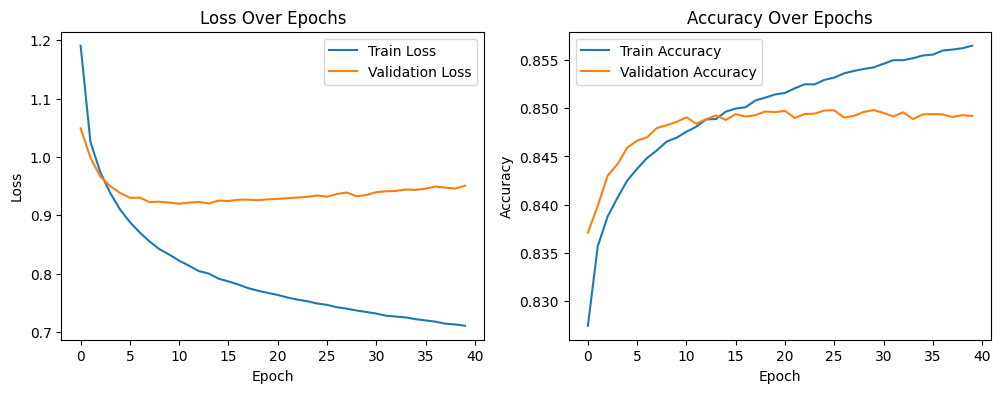

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Embedding, Dropout, Add, TimeDistributed
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
import numpy as np
import pandas as pd
from PIL import Image
import os
import json
import matplotlib.pyplot as plt
import random
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction


tf.keras.backend.clear_session()

#vocabulary
with open('tokenizer_vocab.json', 'r') as f:
    vocab = json.load(f)
vocab_size = len(vocab)
word_to_idx = vocab
idx_to_word = {idx: word for word, idx in vocab.items()}
max_length = 35

def clean_caption(caption):
    try:
        if isinstance(caption, str):
            for token in ['<sos>', '<eos>', '<pad>']:
                caption = caption.replace(token, '')
            return ' '.join(caption.lower().strip().split())
        elif isinstance(caption, list):
            cleaned = [clean_caption(cap) for cap in caption if isinstance(cap, str) and cap]
            return cleaned if cleaned else ['']
        else:
            print(f"Invalid caption type: {type(caption)}")
            return ['']
    except Exception as e:
        print(f"Error cleaning caption: {e}")
        return ['']

def text_to_sequence(caption, vocab):
    cleaned = clean_caption(caption)
    if isinstance(cleaned, list):
        cleaned = cleaned[0] if cleaned else ''
    if not cleaned:
        return []
    return [vocab.get(word, vocab['<unk>']) for word in cleaned.split()]

#data_generator
def data_generator(df, image_dir, batch_size, max_length, vocab):
    while True:
        df = df.sample(frac=1).reset_index(drop=True)
        for start in range(0, len(df), batch_size):
            end = min(start + batch_size, len(df))
            batch_df = df[start:end]
            
            images = []
            captions_in = []
            captions_out = []
            
            for _, row in batch_df.iterrows():
                img_path = os.path.join(image_dir, row['image'])
                try:
                    img = Image.open(img_path).resize((224, 224))
                    img_array = np.array(img)
                    img_array = preprocess_input(img_array)
                    images.append(img_array)
                    
                    seq = text_to_sequence(row['caption'], vocab)
                    seq = [vocab['<sos>']] + seq + [vocab['<eos>']]
                    in_seq = pad_sequences([seq[:-1]], maxlen=max_length, padding='post')[0]
                    out_seq = pad_sequences([seq[1:]], maxlen=max_length, padding='post')[0]
                    captions_in.append(in_seq)
                    captions_out.append(out_seq)
                except Exception as e:
                    print(f"Error processing image {img_path}: {e}")
                    continue
            
            if len(images) == 0 or len(captions_in) == 0:
                continue
                
            yield (
                {
                    'input_1': np.array(images, dtype=np.float32),
                    'input_2': np.array(captions_in, dtype=np.int32)
                },
                np.array(captions_out, dtype=np.int32)
            )

#create_tf.data.Dataset
def create_dataset(df, image_dir, batch_size, max_length, vocab):
    dataset = tf.data.Dataset.from_generator(
        lambda: data_generator(df, image_dir, batch_size, max_length, vocab),
        output_signature=(
            {
                'input_1': tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_1'),
                'input_2': tf.TensorSpec(shape=(None, max_length), dtype=tf.int32, name='input_2')
            },
            tf.TensorSpec(shape=(None, max_length), dtype=tf.int32)
        )
    )
    return dataset.prefetch(tf.data.AUTOTUNE)

#ResNet50 encoder
def build_backbone_model():
    input_layer = Input(shape=(224, 224, 3), name='input_1')
    base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=input_layer)
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu', dtype='float32')(x)
    image_features = Dropout(0.5)(x)
    
    for layer in base_model.layers:
        layer.trainable = False
    
    return Model(inputs=input_layer, outputs=image_features)

#build hybrid LSTM-GRU decoder
def build_lstm_gru_model(vocab_size, max_length, embedding_dim=256):
    caption_input = Input(shape=(max_length,), name='input_2')
    x = Embedding(vocab_size, embedding_dim, mask_zero=True)(caption_input)
    x = LSTM(256, return_sequences=True, dtype='float32')(x)
    x = Dropout(0.5)(x)
    x = GRU(256, return_sequences=True, dtype='float32')(x)
    caption_features = Dropout(0.5)(x)
    
    return caption_input, caption_features

#combine_models in hybrid
def build_captioning_model(vocab_size, max_length):
    backbone_model = build_backbone_model()
    image_input = backbone_model.input
    image_features = backbone_model.output
    
    caption_input, caption_features = build_lstm_gru_model(vocab_size, max_length)
    
    image_features = tf.keras.layers.RepeatVector(max_length)(image_features)
    combined = Add()([image_features, caption_features])
    x = TimeDistributed(Dense(256, activation='relu', dtype='float32'))(combined)
    output = TimeDistributed(Dense(vocab_size, activation='softmax', dtype='float32'))(x)
    
    model = Model(inputs=[image_input, caption_input], outputs=output)
    return model

#Beam_search inference
def beam_search_predictions(model, image, vocab, idx_to_word, max_length, beam_width=5):
    start_token = [vocab['<sos>']]
    sequences = [[start_token, 0.0]]
    
    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)
    
    for _ in range(max_length):
        all_candidates = []
        for seq, score in sequences:
            if seq[-1] == vocab['<eos>']:
                all_candidates.append([seq, score])
                continue
            padded_seq = pad_sequences([seq], maxlen=max_length, padding='post')[0]
            padded_seq = np.expand_dims(padded_seq, axis=0)
            preds = model.predict([image, padded_seq], verbose=0)[:, len(seq)-1, :]
            top_words = np.argsort(preds[0])[-beam_width:]
            for word in top_words:
                new_seq = seq + [word]
                new_score = score + np.log(preds[0][word] + 1e-10)
                all_candidates.append([new_seq, new_score])
        
        sequences = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:beam_width]
    
    best_seq = sequences[0][0]
    caption = [idx_to_word[idx] for idx in best_seq if idx not in [vocab['<sos>'], vocab['<eos>'], vocab['<pad>']]]
    return ' '.join(caption)

#Greedy_search inference
def greedy_search_predictions(model, image, vocab, idx_to_word, max_length):
    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)
    
    seq = [vocab['<sos>']]
    for _ in range(max_length):
        padded_seq = pad_sequences([seq], maxlen=max_length, padding='post')[0]
        padded_seq = np.expand_dims(padded_seq, axis=0)
        preds = model.predict([image, padded_seq], verbose=0)[:, len(seq)-1, :]
        next_word = np.argmax(preds[0])
        seq.append(next_word)
        if next_word == vocab['<eos>']:
            break
    
    caption = [idx_to_word[idx] for idx in seq if idx not in [vocab['<sos>'], vocab['<eos>'], vocab['<pad>']]]
    return ' '.join(caption)

#parameters_from_paper
batch_size = 32
embedding_dim = 256
epochs = 40
learning_rate = 0.001

#compile_model
model = build_captioning_model(vocab_size, max_length)
model.compile(optimizer=Adam(learning_rate=learning_rate), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Model input names:", [input.name for input in model.inputs])
print("Model output shape:", model.output_shape)

#create_datasets
train_dataset = create_dataset(train_df, '/kaggle/working/resized_train_images/', batch_size, max_length, vocab)
val_dataset = create_dataset(val_df, '/kaggle/working/resized_val_images/', batch_size, max_length, vocab)

steps_per_epoch = len(train_df) // batch_size
validation_steps = len(val_df) // batch_size

#train
history = model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_dataset,
    validation_steps=validation_steps,
    epochs=epochs,
    verbose=1
)

model.save('image_captioning_model.h5')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('training_history.png')

#evaluation
def evaluate_model(model, test_df, image_dir, vocab, idx_to_word, max_length, num_images=5):
    bleu_scores = {
        'greedy': {1: [], 2: [], 3: [], 4: []},
        'beam_3': {1: [], 2: [], 3: [], 4: []},
        'beam_5': {1: [], 2: [], 3: [], 4: []}
    }
    
    #5 random samples
    selected_images = test_df.sample(n=num_images, random_state=42).reset_index(drop=True)
    
    print("\nEvaluating 5 Sample Images:")
    print("="*50)
    plt.figure(figsize=(15, 10))
    
    for idx, row in selected_images.iterrows():
        img_path = os.path.join(image_dir, row['image'])
        try:
            img = Image.open(img_path).resize((224, 224))
            img_array = np.array(img)
            

            greedy_caption = greedy_search_predictions(model, img_array, vocab, idx_to_word, max_length)
            beam_caption_3 = beam_search_predictions(model, img_array, vocab, idx_to_word, max_length, beam_width=3)
            beam_caption_5 = beam_search_predictions(model, img_array, vocab, idx_to_word, max_length, beam_width=5)
            
            if 'captions' in row and isinstance(row['captions'], (list, tuple)):
                reference_captions = clean_caption(row['captions'])
            else:
                reference_captions = clean_caption(row['caption'])
            if isinstance(reference_captions, str):
                reference_captions = [reference_captions]
            reference_captions = [cap.split() for cap in reference_captions if cap]
            if not reference_captions:
                print(f"Skipping image {img_path}: No valid reference captions")
                continue

            greedy_words = greedy_caption.split()
            beam_words_3 = beam_caption_3.split()
            beam_words_5 = beam_caption_5.split()
            print(f"\nImage {idx+1}: {row['image']}")
            print(f"Reference Caption(s): {', '.join([' '.join(ref) for ref in reference_captions])}")
            print(f"Greedy Search Caption: {greedy_caption}")
            print(f"Beam Search (width=3) Caption: {beam_caption_3}")
            print(f"Beam Search (width=5) Caption: {beam_caption_5}")
            
            #compute BLEU-1 to BLEU-4
            for n in range(1, 5):
                weights = [1.0/n] + [0.0]*(n-1)
                bleu_greedy = sentence_bleu(reference_captions, greedy_words, weights=weights,
                                           smoothing_function=SmoothingFunction().method1)
                bleu_beam_3 = sentence_bleu(reference_captions, beam_words_3, weights=weights,
                                           smoothing_function=SmoothingFunction().method1)
                bleu_beam_5 = sentence_bleu(reference_captions, beam_words_5, weights=weights,
                                           smoothing_function=SmoothingFunction().method1)
                bleu_scores['greedy'][n].append(bleu_greedy)
                bleu_scores['beam_3'][n].append(bleu_beam_3)
                bleu_scores['beam_5'][n].append(bleu_beam_5)
            
            plt.subplot(2, 3, idx + 1)
            plt.imshow(img)
            plt.title(f"Image {idx+1}\nGreedy: {greedy_caption[:20]}...\nBeam(3): {beam_caption_3[:20]}...\nBeam(5): {beam_caption_5[:20]}...")
            plt.axis('off')
        
        except Exception as e:
            print(f"Error evaluating image {img_path}: {e}")
            continue
    
    plt.tight_layout()
    plt.savefig('sample_images_with_captions.png')
    
    print("\nBLEU Evaluation Results (5 Samples):")
    print("="*50)
    for n in range(1, 5):
        print(f"Average BLEU-{n} (Greedy Search): {np.mean(bleu_scores['greedy'][n]):.4f}")
        print(f"Average BLEU-{n} (Beam Search, width=3): {np.mean(bleu_scores['beam_3'][n]):.4f}")
        print(f"Average BLEU-{n} (Beam Search, width=5): {np.mean(bleu_scores['beam_5'][n]):.4f}")

evaluate_model(model, test_df, '/kaggle/working/resized_test_images/', vocab, idx_to_word, max_length)

Model input names: ['input_1', 'input_2']
Model output shape: (None, 35, 7462)
Epoch 1/12
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 149s 129ms/step - accuracy: 0.8147 - loss: 1.4792 - val_accuracy: 0.8376 - val_loss: 1.0451
Epoch 2/12
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 122s 121ms/step - accuracy: 0.8352 - loss: 1.0340 - val_accuracy: 0.8401 - val_loss: 0.9993
Epoch 3/12
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 123s 121ms/step - accuracy: 0.8384 - loss: 0.9755 - val_accuracy: 0.8423 - val_loss: 0.9686
Epoch 4/12
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 123s 121ms/step - accuracy: 0.8403 - loss: 0.9379 - val_accuracy: 0.8443 - val_loss: 0.9508
Epoch 5/12
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 123s 122ms/step - accuracy: 0.8424 - loss: 0.9095 - val_accuracy: 0.8457 - val_loss: 0.9382
Epoch 6/12
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 122s 121ms/step - accuracy: 0.8436 - loss: 0.8881 - val_accuracy: 0.8464 - val_loss: 0.9295
Epoch 7/12
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 122s 121ms/step - accuracy: 0.8440 - loss: 0.8730 - val_accuracy: 0.8470 - 

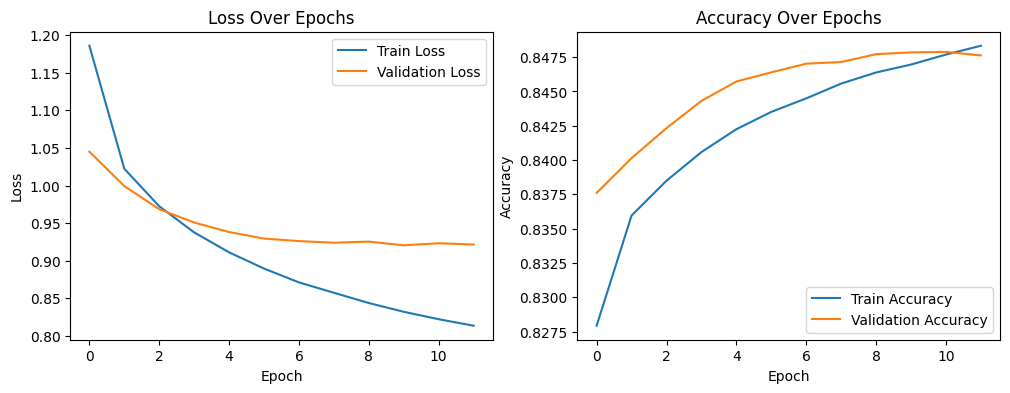

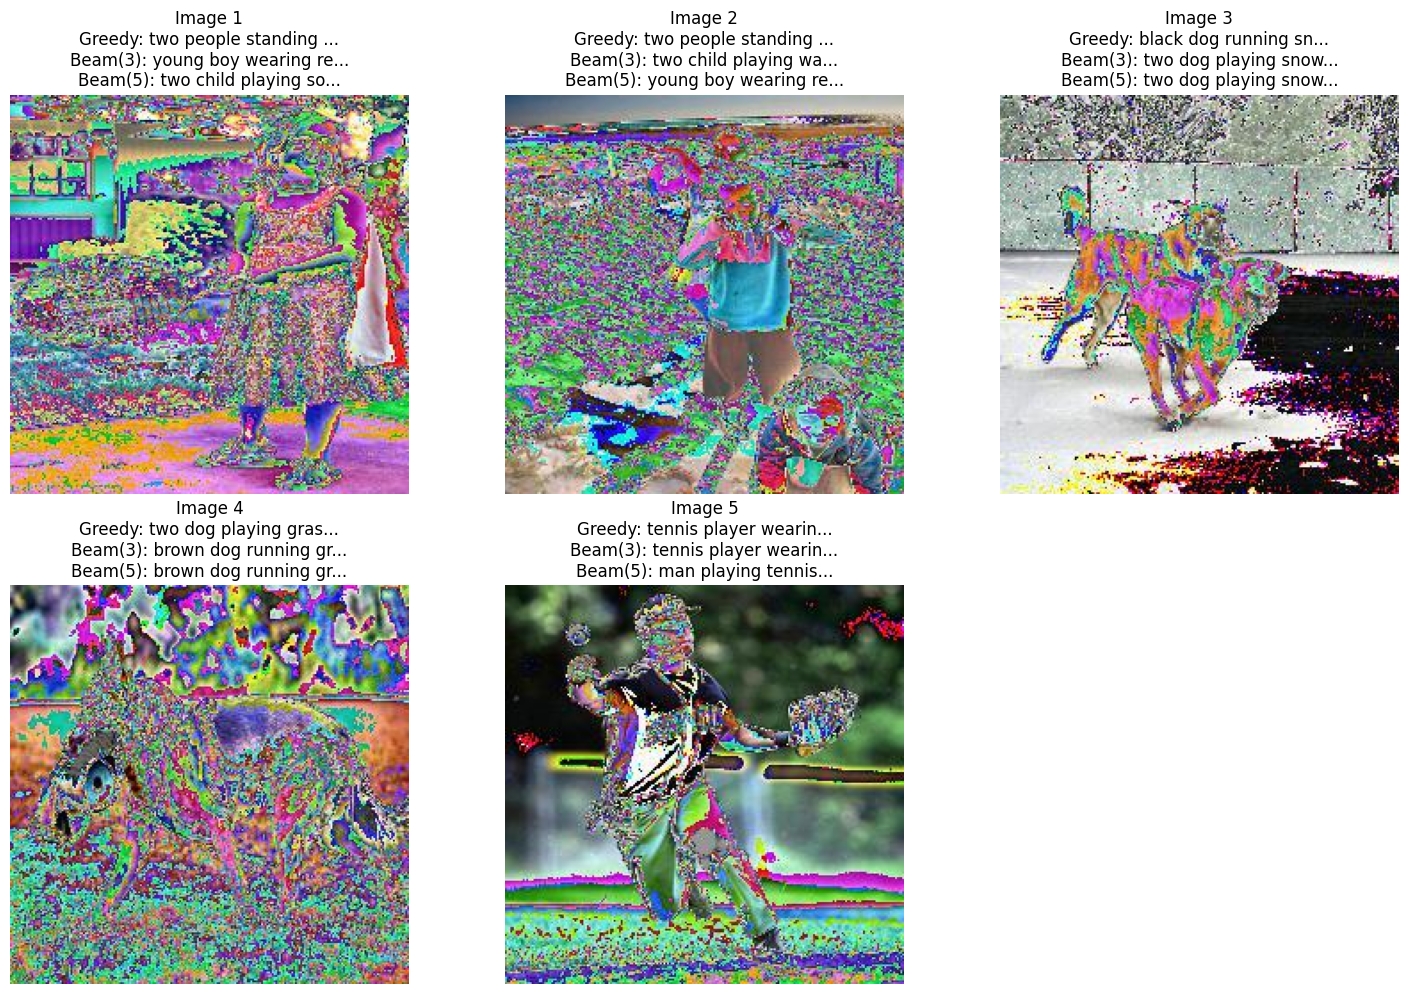

In [45]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Embedding, Dropout, Add, TimeDistributed
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
import numpy as np
import pandas as pd
from PIL import Image
import os
import json
import matplotlib.pyplot as plt
import random
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction


tf.keras.backend.clear_session()

#vocabulary
with open('tokenizer_vocab.json', 'r') as f:
    vocab = json.load(f)
vocab_size = len(vocab)
word_to_idx = vocab
idx_to_word = {idx: word for word, idx in vocab.items()}
max_length = 35

def clean_caption(caption):
    try:
        if isinstance(caption, str):
            for token in ['<sos>', '<eos>', '<pad>']:
                caption = caption.replace(token, '')
            return ' '.join(caption.lower().strip().split())
        elif isinstance(caption, list):
            cleaned = [clean_caption(cap) for cap in caption if isinstance(cap, str) and cap]
            return cleaned if cleaned else ['']
        else:
            print(f"Invalid caption type: {type(caption)}")
            return ['']
    except Exception as e:
        print(f"Error cleaning caption: {e}")
        return ['']

def text_to_sequence(caption, vocab):
    cleaned = clean_caption(caption)
    if isinstance(cleaned, list):
        cleaned = cleaned[0] if cleaned else ''
    if not cleaned:
        return []
    return [vocab.get(word, vocab['<unk>']) for word in cleaned.split()]

#data_generator
def data_generator(df, image_dir, batch_size, max_length, vocab):
    while True:
        df = df.sample(frac=1).reset_index(drop=True)
        for start in range(0, len(df), batch_size):
            end = min(start + batch_size, len(df))
            batch_df = df[start:end]
            
            images = []
            captions_in = []
            captions_out = []
            
            for _, row in batch_df.iterrows():
                img_path = os.path.join(image_dir, row['image'])
                try:
                    img = Image.open(img_path).resize((224, 224))
                    img_array = np.array(img)
                    img_array = preprocess_input(img_array)
                    images.append(img_array)
                    
                    seq = text_to_sequence(row['caption'], vocab)
                    seq = [vocab['<sos>']] + seq + [vocab['<eos>']]
                    in_seq = pad_sequences([seq[:-1]], maxlen=max_length, padding='post')[0]
                    out_seq = pad_sequences([seq[1:]], maxlen=max_length, padding='post')[0]
                    captions_in.append(in_seq)
                    captions_out.append(out_seq)
                except Exception as e:
                    print(f"Error processing image {img_path}: {e}")
                    continue
            
            if len(images) == 0 or len(captions_in) == 0:
                continue
                
            yield (
                {
                    'input_1': np.array(images, dtype=np.float32),
                    'input_2': np.array(captions_in, dtype=np.int32)
                },
                np.array(captions_out, dtype=np.int32)
            )

#create_tf.data.Dataset
def create_dataset(df, image_dir, batch_size, max_length, vocab):
    dataset = tf.data.Dataset.from_generator(
        lambda: data_generator(df, image_dir, batch_size, max_length, vocab),
        output_signature=(
            {
                'input_1': tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_1'),
                'input_2': tf.TensorSpec(shape=(None, max_length), dtype=tf.int32, name='input_2')
            },
            tf.TensorSpec(shape=(None, max_length), dtype=tf.int32)
        )
    )
    return dataset.prefetch(tf.data.AUTOTUNE)

#ResNet50 encoder
def build_backbone_model():
    input_layer = Input(shape=(224, 224, 3), name='input_1')
    base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=input_layer)
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu', dtype='float32')(x)
    image_features = Dropout(0.5)(x)
    
    for layer in base_model.layers:
        layer.trainable = False
    
    return Model(inputs=input_layer, outputs=image_features)

#build hybrid LSTM-GRU decoder
def build_lstm_gru_model(vocab_size, max_length, embedding_dim=256):
    caption_input = Input(shape=(max_length,), name='input_2')
    x = Embedding(vocab_size, embedding_dim, mask_zero=True)(caption_input)
    x = LSTM(256, return_sequences=True, dtype='float32')(x)
    x = Dropout(0.5)(x)
    x = GRU(256, return_sequences=True, dtype='float32')(x)
    caption_features = Dropout(0.5)(x)
    
    return caption_input, caption_features

#combine_models in hybrid Class
def build_captioning_model(vocab_size, max_length):
    backbone_model = build_backbone_model()
    image_input = backbone_model.input
    image_features = backbone_model.output
    
    caption_input, caption_features = build_lstm_gru_model(vocab_size, max_length)
    
    image_features = tf.keras.layers.RepeatVector(max_length)(image_features)
    combined = Add()([image_features, caption_features])
    x = TimeDistributed(Dense(256, activation='relu', dtype='float32'))(combined)
    output = TimeDistributed(Dense(vocab_size, activation='softmax', dtype='float32'))(x)
    
    model = Model(inputs=[image_input, caption_input], outputs=output)
    return model

#Beam_search inference
def beam_search_predictions(model, image, vocab, idx_to_word, max_length, beam_width=5):
    start_token = [vocab['<sos>']]
    sequences = [[start_token, 0.0]]
    
    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)
    
    for _ in range(max_length):
        all_candidates = []
        for seq, score in sequences:
            if seq[-1] == vocab['<eos>']:
                all_candidates.append([seq, score])
                continue
            padded_seq = pad_sequences([seq], maxlen=max_length, padding='post')[0]
            padded_seq = np.expand_dims(padded_seq, axis=0)
            preds = model.predict([image, padded_seq], verbose=0)[:, len(seq)-1, :]
            top_words = np.argsort(preds[0])[-beam_width:]
            for word in top_words:
                new_seq = seq + [word]
                new_score = score + np.log(preds[0][word] + 1e-10)
                all_candidates.append([new_seq, new_score])
        
        sequences = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:beam_width]
    
    best_seq = sequences[0][0]
    caption = [idx_to_word[idx] for idx in best_seq if idx not in [vocab['<sos>'], vocab['<eos>'], vocab['<pad>']]]
    return ' '.join(caption)

#Greedy_search inference
def greedy_search_predictions(model, image, vocab, idx_to_word, max_length):
    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)
    
    seq = [vocab['<sos>']]
    for _ in range(max_length):
        padded_seq = pad_sequences([seq], maxlen=max_length, padding='post')[0]
        padded_seq = np.expand_dims(padded_seq, axis=0)
        preds = model.predict([image, padded_seq], verbose=0)[:, len(seq)-1, :]
        next_word = np.argmax(preds[0])
        seq.append(next_word)
        if next_word == vocab['<eos>']:
            break
    
    caption = [idx_to_word[idx] for idx in seq if idx not in [vocab['<sos>'], vocab['<eos>'], vocab['<pad>']]]
    return ' '.join(caption)

#parameters_from_paper
batch_size = 32
embedding_dim = 256
epochs = 12
learning_rate = 0.001

#compile_model
model = build_captioning_model(vocab_size, max_length)
model.compile(optimizer=Adam(learning_rate=learning_rate), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Model input names:", [input.name for input in model.inputs])
print("Model output shape:", model.output_shape)

#create_datasets
train_dataset = create_dataset(train_df, '/kaggle/working/resized_train_images/', batch_size, max_length, vocab)
val_dataset = create_dataset(val_df, '/kaggle/working/resized_val_images/', batch_size, max_length, vocab)

steps_per_epoch = len(train_df) // batch_size
validation_steps = len(val_df) // batch_size

#train
history = model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_dataset,
    validation_steps=validation_steps,
    epochs=epochs,
    verbose=1
)

model.save('image_captioning_model.h5')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('training_history.png')

#evaluation
def evaluate_model(model, test_df, image_dir, vocab, idx_to_word, max_length, num_images=5):
    bleu_scores = {
        'greedy': {1: [], 2: [], 3: [], 4: []},
        'beam_3': {1: [], 2: [], 3: [], 4: []},
        'beam_5': {1: [], 2: [], 3: [], 4: []}
    }
    
    #5 random samples
    selected_images = test_df.sample(n=num_images, random_state=42).reset_index(drop=True)
    
    print("\nEvaluating 5 Sample Images:")
    print("="*50)
    plt.figure(figsize=(15, 10))
    
    for idx, row in selected_images.iterrows():
        img_path = os.path.join(image_dir, row['image'])
        try:
            img = Image.open(img_path).resize((224, 224))
            img_array = np.array(img)
            

            greedy_caption = greedy_search_predictions(model, img_array, vocab, idx_to_word, max_length)
            beam_caption_3 = beam_search_predictions(model, img_array, vocab, idx_to_word, max_length, beam_width=3)
            beam_caption_5 = beam_search_predictions(model, img_array, vocab, idx_to_word, max_length, beam_width=5)
            
            if 'captions' in row and isinstance(row['captions'], (list, tuple)):
                reference_captions = clean_caption(row['captions'])
            else:
                reference_captions = clean_caption(row['caption'])
            if isinstance(reference_captions, str):
                reference_captions = [reference_captions]
            reference_captions = [cap.split() for cap in reference_captions if cap]
            if not reference_captions:
                print(f"Skipping image {img_path}: No valid reference captions")
                continue

            greedy_words = greedy_caption.split()
            beam_words_3 = beam_caption_3.split()
            beam_words_5 = beam_caption_5.split()
            print(f"\nImage {idx+1}: {row['image']}")
            print(f"Reference Caption(s): {', '.join([' '.join(ref) for ref in reference_captions])}")
            print(f"Greedy Search Caption: {greedy_caption}")
            print(f"Beam Search (width=3) Caption: {beam_caption_3}")
            print(f"Beam Search (width=5) Caption: {beam_caption_5}")
            
            #compute BLEU-1 to BLEU-4
            for n in range(1, 5):
                weights = [1.0/n] + [0.0]*(n-1)
                bleu_greedy = sentence_bleu(reference_captions, greedy_words, weights=weights,
                                           smoothing_function=SmoothingFunction().method1)
                bleu_beam_3 = sentence_bleu(reference_captions, beam_words_3, weights=weights,
                                           smoothing_function=SmoothingFunction().method1)
                bleu_beam_5 = sentence_bleu(reference_captions, beam_words_5, weights=weights,
                                           smoothing_function=SmoothingFunction().method1)
                bleu_scores['greedy'][n].append(bleu_greedy)
                bleu_scores['beam_3'][n].append(bleu_beam_3)
                bleu_scores['beam_5'][n].append(bleu_beam_5)
            
            plt.subplot(2, 3, idx + 1)
            plt.imshow(img)
            plt.title(f"Image {idx+1}\nGreedy: {greedy_caption[:20]}...\nBeam(3): {beam_caption_3[:20]}...\nBeam(5): {beam_caption_5[:20]}...")
            plt.axis('off')
        
        except Exception as e:
            print(f"Error evaluating image {img_path}: {e}")
            continue
    
    plt.tight_layout()
    plt.savefig('sample_images_with_captions.png')
    
    print("\nBLEU Evaluation Results (5 Samples):")
    print("="*50)
    for n in range(1, 5):
        print(f"Average BLEU-{n} (Greedy Search): {np.mean(bleu_scores['greedy'][n]):.4f}")
        print(f"Average BLEU-{n} (Beam Search, width=3): {np.mean(bleu_scores['beam_3'][n]):.4f}")
        print(f"Average BLEU-{n} (Beam Search, width=5): {np.mean(bleu_scores['beam_5'][n]):.4f}")

evaluate_model(model, test_df, '/kaggle/working/resized_test_images/', vocab, idx_to_word, max_length)

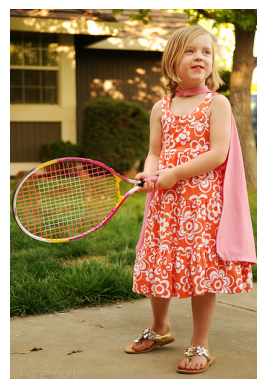

<sos> girl dress hold tennis racket <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> little girl red dress cape hold large tennis racquet <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> little girl red flowered dress tennis racket <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> young girl orange dress holding tennis racket <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> little girl red flowered dress pink cape holding racket <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>


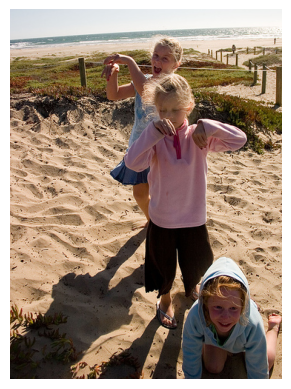

<sos> three child playing sand near beach <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> three child playing sand beach <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> three girl play sand <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> three little blond girl two blue one pink play sunny beach <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> three young girl dance beach sand <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>


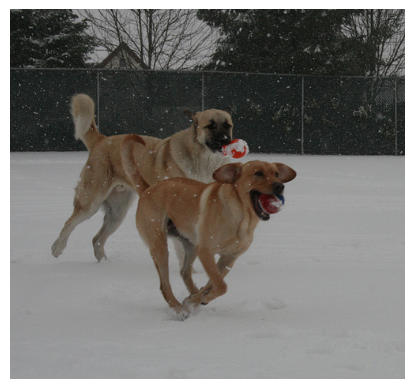

<sos> dog chase another dog <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> two dog running snow ball mouth <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> two dog holding red ball mouth running snow <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> two dog snow <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> two tan dog run snow carrying red ball mouth <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>


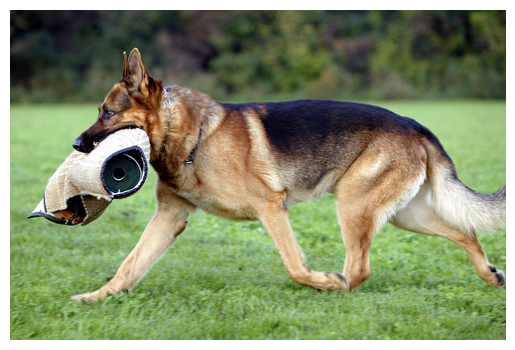

<sos> brown dog fetching something mouth field <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> dog field holding something mouth <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> dog carrying something mouth <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> dog choke collar holding gauntlet mouth <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> large black brown dog carrying something mouth walking grass <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>


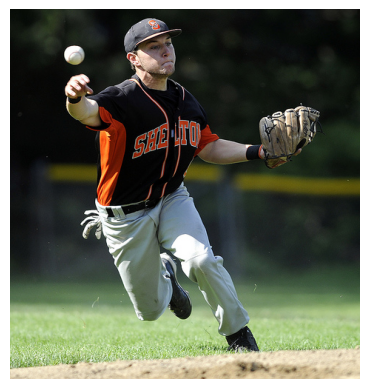

<sos> baseball pitcher shelton shirt throw ball <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> baseball player black orange shirt glove pitch ball <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> male dressed sport outfit try catch baseball <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> man playing baseball <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>
<sos> baseball player running ball <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <eos>


In [46]:
from PIL import Image
import matplotlib.pyplot as plt
last_image = "khali"
counter = 0
image_lists = ['3447155358_5b5b59b15e.jpg','1248940539_46d33ed487.jpg','3117562746_62f57a02b5.jpg','3286198467_8880be127e.jpg','3603116579_4a28a932e2.jpg']
for image in image_lists:
    if image != last_image:
        img = Image.open('/kaggle/input/flickr8k/Images/'+str(image))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        #print(len(df_captions[df_captions['image'] == image].caption))
        captions = df_captions[df_captions['image'] == image].caption
        for i in range(len(captions)):
            print(captions.iloc[i])
        last_image = str(image)